Dataset loaded successfully!

FIRST 5 ROWS
     ID  Year_Birth   Education Marital_Status   Income  Kidhome  Teenhome  \
0  5524        1957  Graduation         Single  58138.0        0         0   
1  2174        1954  Graduation         Single  46344.0        1         1   
2  4141        1965  Graduation       Together  71613.0        0         0   
3  6182        1984  Graduation       Together  26646.0        1         0   
4  5324        1981         PhD        Married  58293.0        1         0   

  Dt_Customer  Recency  MntWines  ...  NumWebVisitsMonth  AcceptedCmp3  \
0  04-09-2012       58       635  ...                  7             0   
1  08-03-2014       38        11  ...                  5             0   
2  21-08-2013       26       426  ...                  4             0   
3  10-02-2014       26        11  ...                  6             0   
4  19-01-2014       94       173  ...                  5             0   

   AcceptedCmp4  AcceptedCmp5  AcceptedCmp1

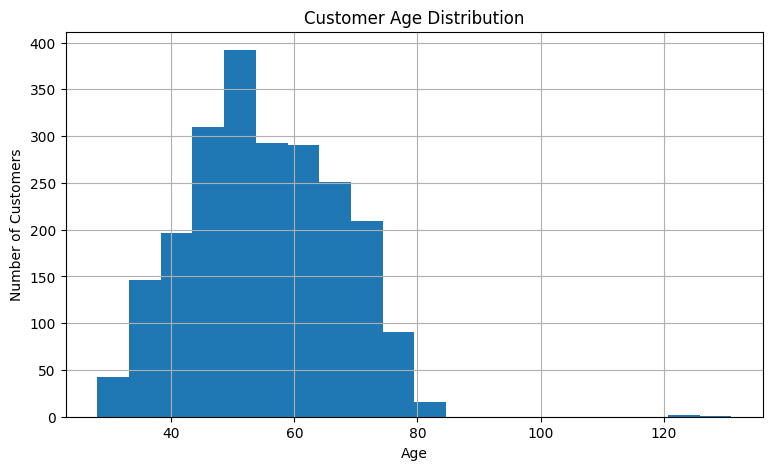

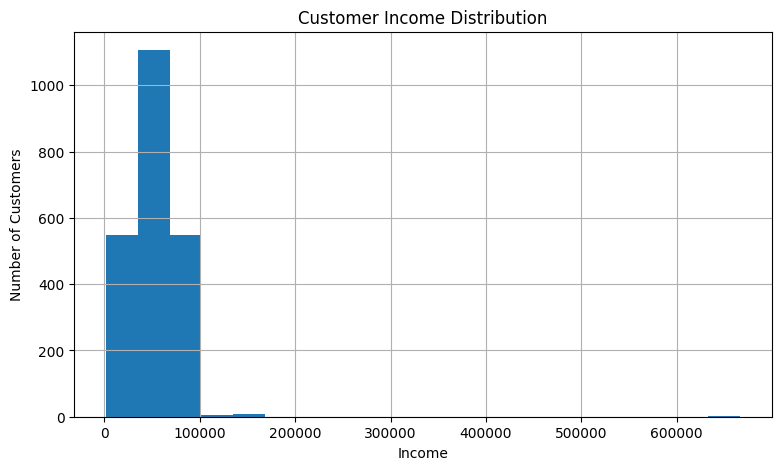

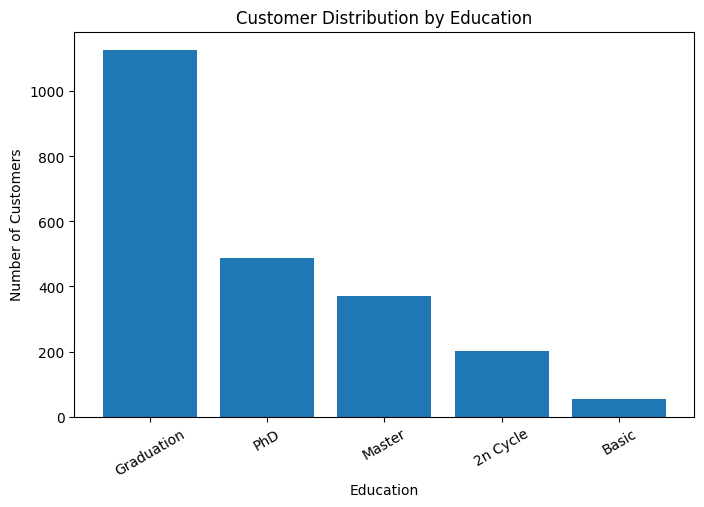

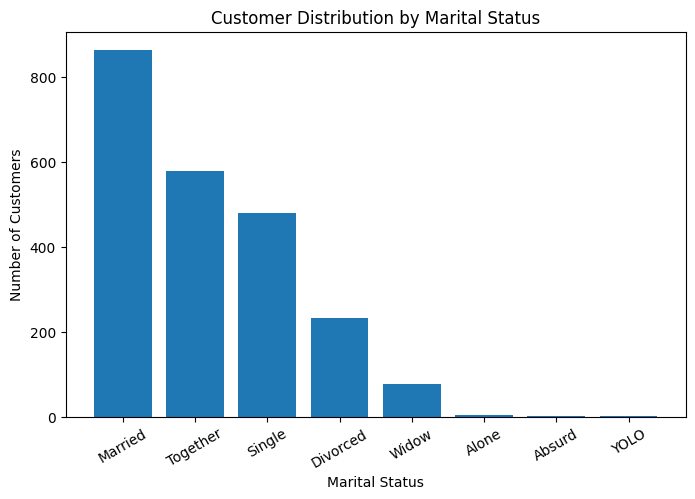

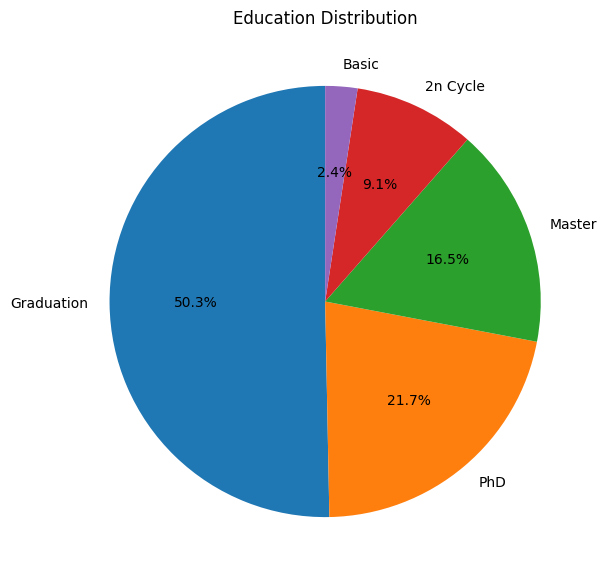

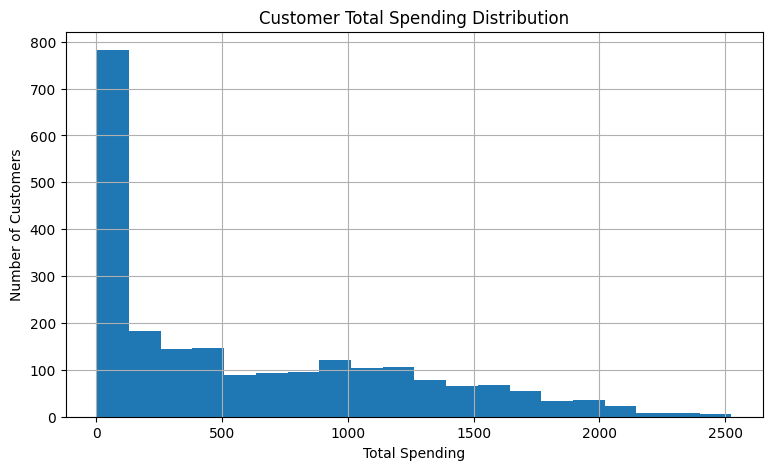

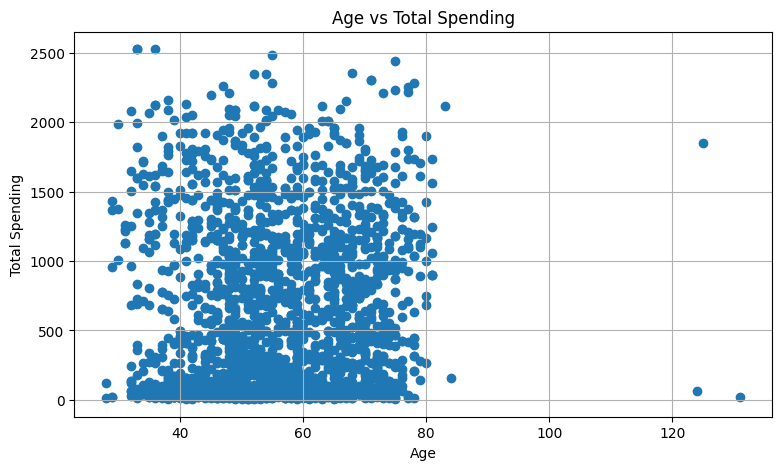

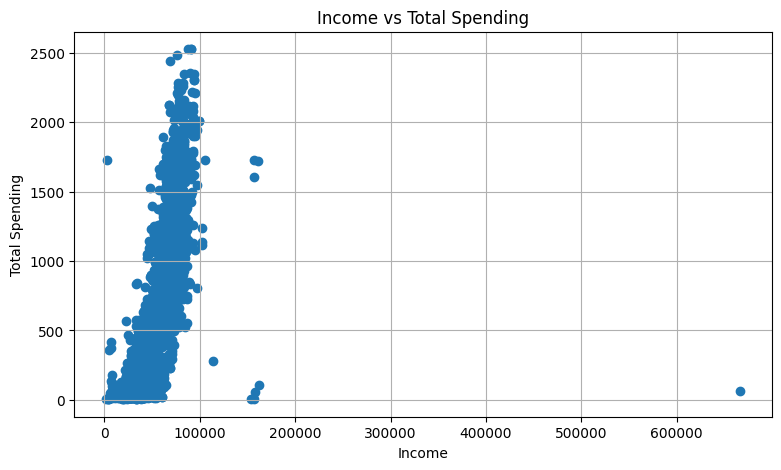

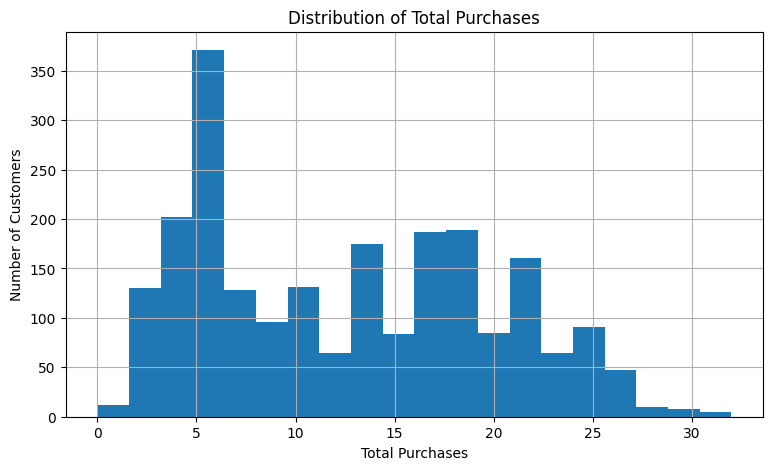

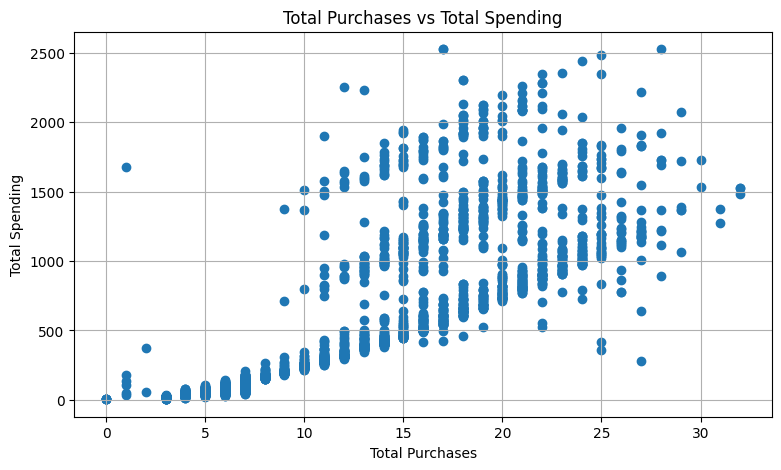

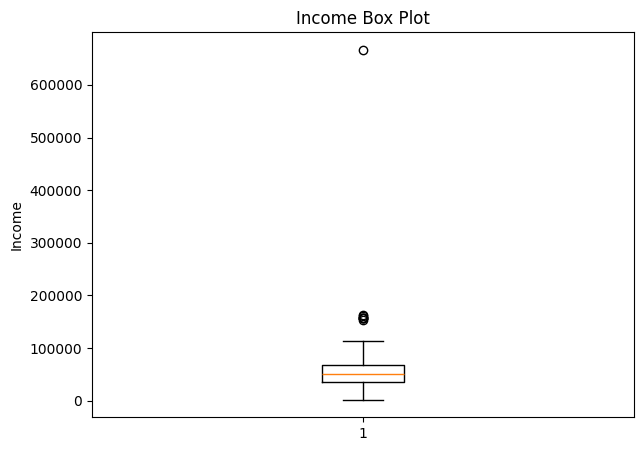

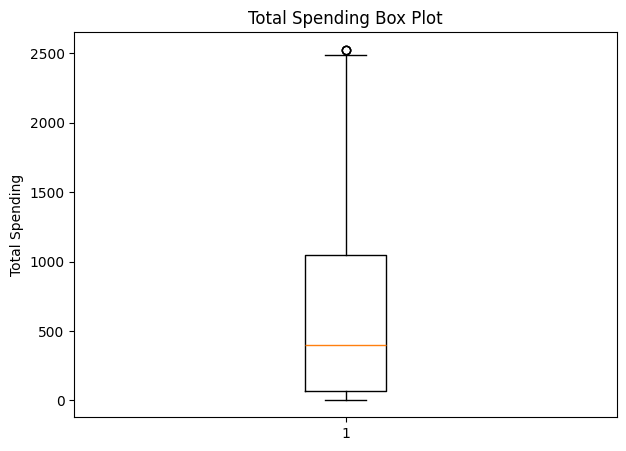

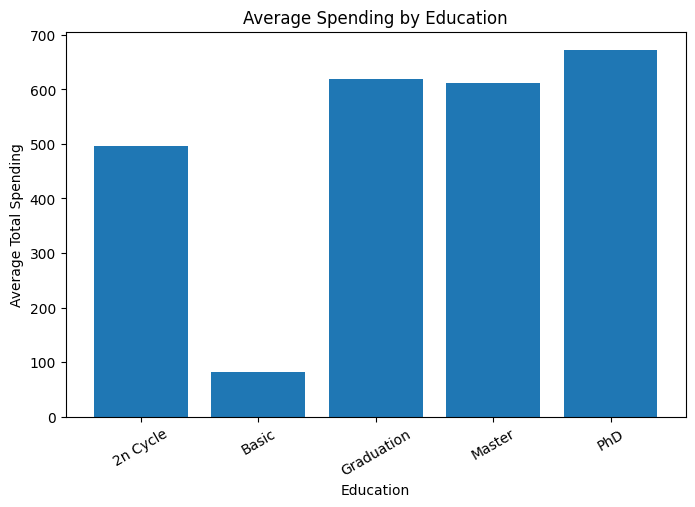

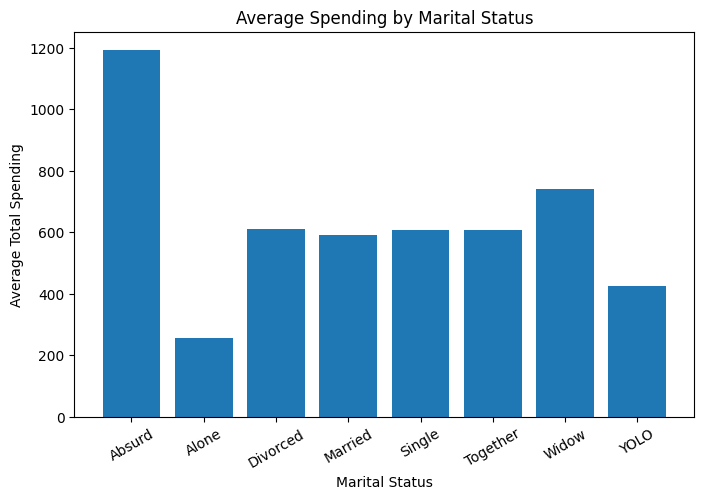

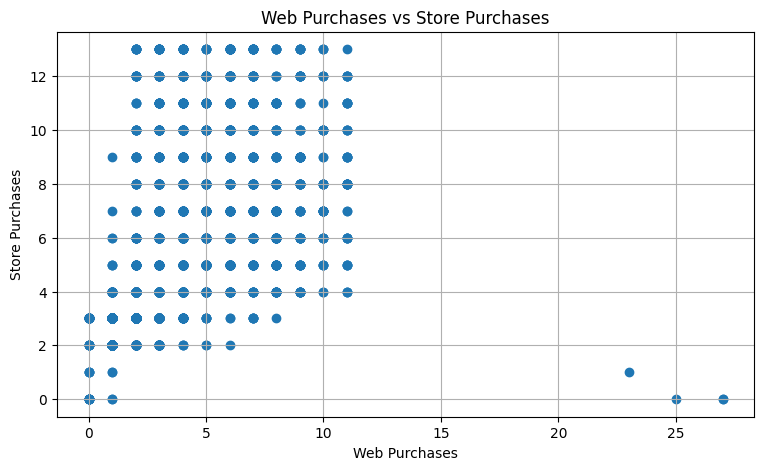

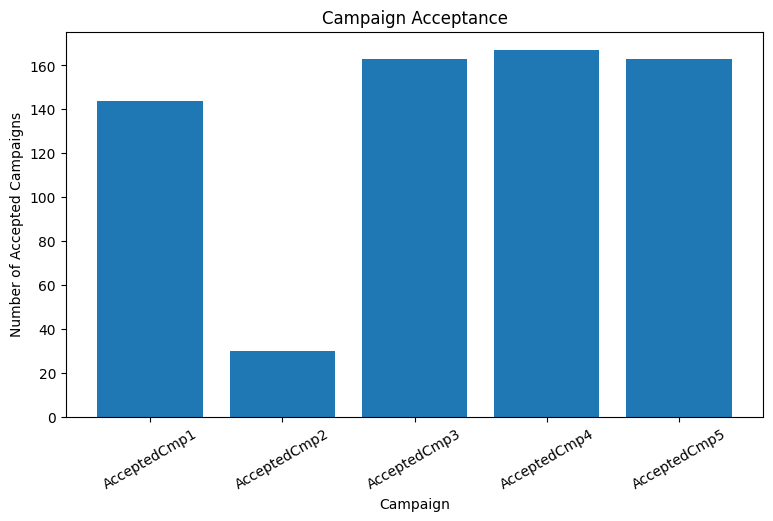

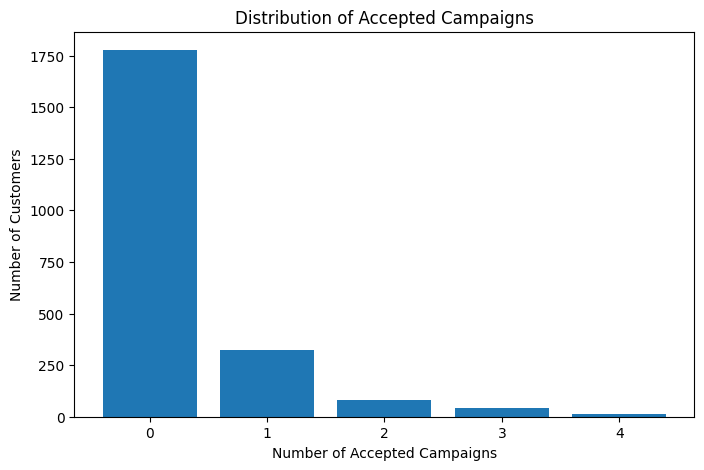


CORRELATION MATRIX
                                ID  Year_Birth    Income   Kidhome  Teenhome  \
ID                        1.000000    0.000028  0.013095  0.002406 -0.002580   
Year_Birth                0.000028    1.000000 -0.161791  0.230176 -0.352111   
Income                    0.013095   -0.161791  1.000000 -0.428669  0.019133   
Kidhome                   0.002406    0.230176 -0.428669  1.000000 -0.036133   
Teenhome                 -0.002580   -0.352111  0.019133 -0.036133  1.000000   
Recency                  -0.046524   -0.019871 -0.003970  0.008827  0.016198   
MntWines                 -0.022878   -0.157773  0.578650 -0.496297  0.004846   
MntFruits                 0.004600   -0.017917  0.430842 -0.372581 -0.176764   
MntMeatProducts          -0.004437   -0.030872  0.584633 -0.437129 -0.261160   
MntFishProducts          -0.024475   -0.041625  0.438871 -0.387644 -0.204187   
MntSweetProducts         -0.007642   -0.018133  0.440744 -0.370673 -0.162475   
MntGoldProds        

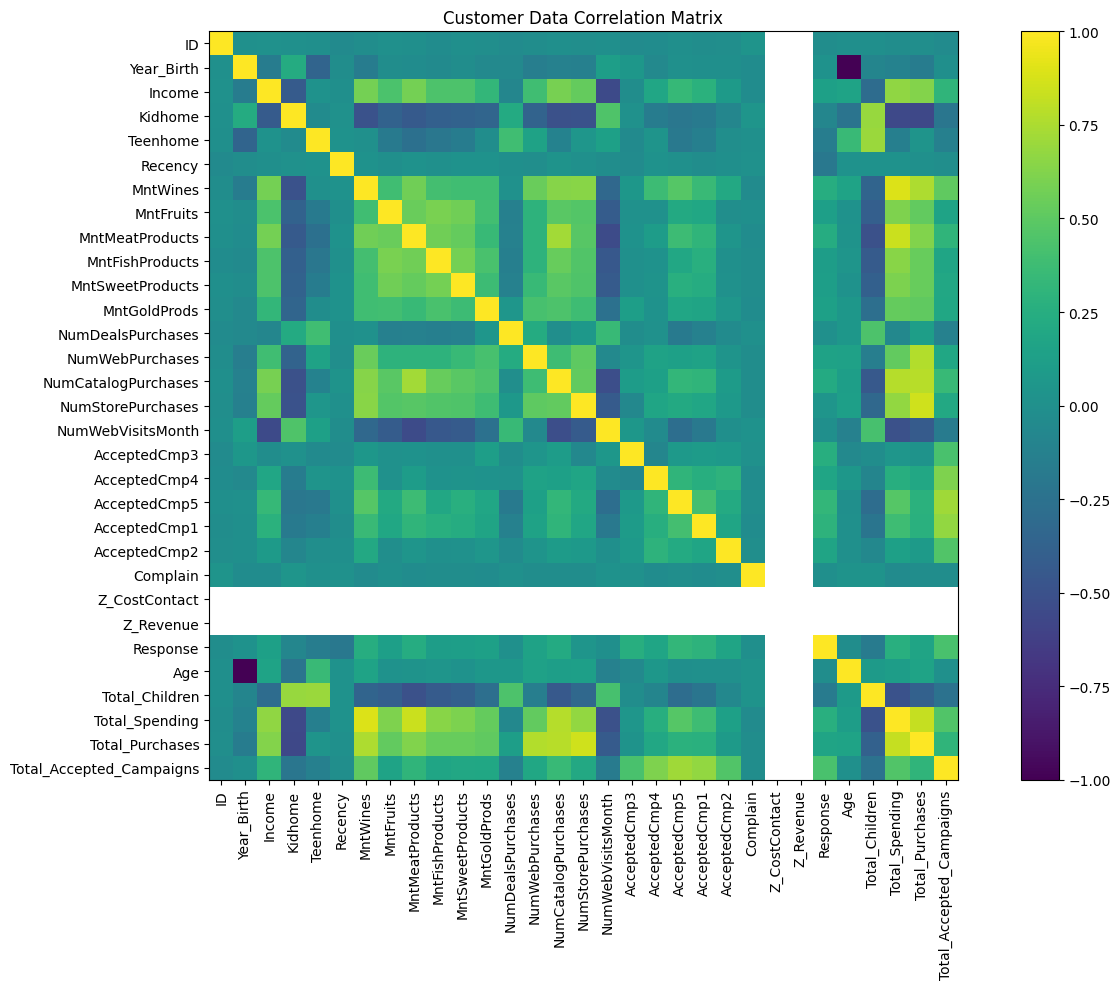


TOP 10 SPENDING CUSTOMERS
         ID   Income  Age  Total_Spending
1572   5350  90638.0   33            2525
1179   5735  90638.0   33            2525
1492   1763  87679.0   36            2524
987    4580  75759.0   55            2486
1052   4475  69098.0   75            2440
1601   5453  90226.0   68            2352
1458  10133  93790.0   54            2349
1288   9010  83151.0   52            2346
1301   6024  94384.0   71            2302
943    5386  94384.0   71            2302

HIGH-VALUE CUSTOMERS
Number of high-value customers: 560
      ID   Income  Age  Total_Spending
0   5524  58138.0   67            1617
12  2125  63033.0   65            1102
15  2114  82800.0   78            1315
18  6565  76995.0   75            1782
21  5376   2447.0   45            1730
29  1966  84618.0   59            1672
34  8755  68657.0   78            1196
40  8601  80011.0   44            1395
49  6566  72550.0   70            1319
51  4114  79143.0   60            1693

CUSTOMER ANALYSIS SUMMA

In [6]:
# ============================================================
# CUSTOMER PERSONALITY ANALYSIS
# Exploratory Data Analysis (EDA)
# Kaggle
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# 1. LOAD DATASET
# ============================================================

file_path = "/kaggle/input/datasets/imakash3011/customer-personality-analysis/marketing_campaign.csv"

df = pd.read_csv(file_path, sep="\t")

print("Dataset loaded successfully!")


# ============================================================
# 2. DISPLAY FIRST 5 ROWS
# ============================================================

print("\nFIRST 5 ROWS")
print("=" * 60)

print(df.head())


# ============================================================
# 3. DISPLAY COMPLETE DATASET
# ============================================================

print("\nCOMPLETE DATASET")
print("=" * 60)

print(df)


# ============================================================
# 4. DISPLAY COLUMN NAMES
# ============================================================

print("\nCOLUMN NAMES")
print("=" * 60)

print(df.columns.tolist())


# ============================================================
# 5. DATASET INFORMATION
# ============================================================

print("\nDATASET INFORMATION")
print("=" * 60)

df.info()


# ============================================================
# 6. MISSING VALUES
# ============================================================

print("\nMISSING VALUES")
print("=" * 60)

print(df.isnull().sum())


# ============================================================
# 7. DUPLICATE VALUES
# ============================================================

print("\nDUPLICATE ROWS")
print("=" * 60)

print("Number of duplicate rows:", df.duplicated().sum())


# ============================================================
# 8. REMOVE DUPLICATES
# ============================================================

data = df.copy()

data = data.drop_duplicates()

print("\nShape after removing duplicates:")
print(data.shape)


# ============================================================
# 9. DATA PREPARATION
# ============================================================

# Convert Dt_Customer to date format
data["Dt_Customer"] = pd.to_datetime(
    data["Dt_Customer"],
    dayfirst=True,
    errors="coerce"
)

# Calculate customer age
data["Age"] = 2024 - data["Year_Birth"]

# Calculate total children
data["Total_Children"] = (
    data["Kidhome"] + data["Teenhome"]
)

# Calculate total spending
data["Total_Spending"] = (
    data["MntWines"] +
    data["MntFruits"] +
    data["MntMeatProducts"] +
    data["MntFishProducts"] +
    data["MntSweetProducts"] +
    data["MntGoldProds"]
)

# Calculate total purchases
data["Total_Purchases"] = (
    data["NumWebPurchases"] +
    data["NumCatalogPurchases"] +
    data["NumStorePurchases"]
)

# Calculate total campaign responses
data["Total_Accepted_Campaigns"] = (
    data["AcceptedCmp1"] +
    data["AcceptedCmp2"] +
    data["AcceptedCmp3"] +
    data["AcceptedCmp4"] +
    data["AcceptedCmp5"]
)

print("\nNew columns created successfully.")


# ============================================================
# 10. DESCRIPTIVE STATISTICS
# ============================================================

print("\nDESCRIPTIVE STATISTICS")
print("=" * 60)

print(data.describe())


# ============================================================
# 11. DATA TYPES
# ============================================================

print("\nDATA TYPES")
print("=" * 60)

print(data.dtypes)


# ============================================================
# 12. CUSTOMER AGE DISTRIBUTION
# ============================================================

plt.figure(figsize=(9, 5))

plt.hist(
    data["Age"],
    bins=20
)

plt.title("Customer Age Distribution")
plt.xlabel("Age")
plt.ylabel("Number of Customers")

plt.grid(True)

plt.show()


# ============================================================
# 13. INCOME DISTRIBUTION
# ============================================================

plt.figure(figsize=(9, 5))

plt.hist(
    data["Income"].dropna(),
    bins=20
)

plt.title("Customer Income Distribution")
plt.xlabel("Income")
plt.ylabel("Number of Customers")

plt.grid(True)

plt.show()


# ============================================================
# 14. EDUCATION DISTRIBUTION
# ============================================================

education_count = data["Education"].value_counts()

plt.figure(figsize=(8, 5))

plt.bar(
    education_count.index,
    education_count.values
)

plt.title("Customer Distribution by Education")
plt.xlabel("Education")
plt.ylabel("Number of Customers")

plt.xticks(rotation=30)

plt.show()


# ============================================================
# 15. MARITAL STATUS DISTRIBUTION
# ============================================================

marital_count = data["Marital_Status"].value_counts()

plt.figure(figsize=(8, 5))

plt.bar(
    marital_count.index,
    marital_count.values
)

plt.title("Customer Distribution by Marital Status")
plt.xlabel("Marital Status")
plt.ylabel("Number of Customers")

plt.xticks(rotation=30)

plt.show()


# ============================================================
# 16. PIE CHART - EDUCATION
# ============================================================

plt.figure(figsize=(7, 7))

plt.pie(
    education_count.values,
    labels=education_count.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Education Distribution")

plt.show()


# ============================================================
# 17. TOTAL SPENDING DISTRIBUTION
# ============================================================

plt.figure(figsize=(9, 5))

plt.hist(
    data["Total_Spending"],
    bins=20
)

plt.title("Customer Total Spending Distribution")
plt.xlabel("Total Spending")
plt.ylabel("Number of Customers")

plt.grid(True)

plt.show()


# ============================================================
# 18. AGE VS TOTAL SPENDING
# ============================================================

plt.figure(figsize=(9, 5))

plt.scatter(
    data["Age"],
    data["Total_Spending"]
)

plt.title("Age vs Total Spending")
plt.xlabel("Age")
plt.ylabel("Total Spending")

plt.grid(True)

plt.show()


# ============================================================
# 19. INCOME VS TOTAL SPENDING
# ============================================================

plot_data = data[
    ["Income", "Total_Spending"]
].dropna()

plt.figure(figsize=(9, 5))

plt.scatter(
    plot_data["Income"],
    plot_data["Total_Spending"]
)

plt.title("Income vs Total Spending")
plt.xlabel("Income")
plt.ylabel("Total Spending")

plt.grid(True)

plt.show()


# ============================================================
# 20. TOTAL PURCHASES DISTRIBUTION
# ============================================================

plt.figure(figsize=(9, 5))

plt.hist(
    data["Total_Purchases"],
    bins=20
)

plt.title("Distribution of Total Purchases")
plt.xlabel("Total Purchases")
plt.ylabel("Number of Customers")

plt.grid(True)

plt.show()


# ============================================================
# 21. TOTAL PURCHASES VS TOTAL SPENDING
# ============================================================

plt.figure(figsize=(9, 5))

plt.scatter(
    data["Total_Purchases"],
    data["Total_Spending"]
)

plt.title("Total Purchases vs Total Spending")
plt.xlabel("Total Purchases")
plt.ylabel("Total Spending")

plt.grid(True)

plt.show()


# ============================================================
# 22. BOX PLOT - INCOME
# ============================================================

plt.figure(figsize=(7, 5))

plt.boxplot(
    data["Income"].dropna()
)

plt.title("Income Box Plot")
plt.ylabel("Income")

plt.show()


# ============================================================
# 23. BOX PLOT - TOTAL SPENDING
# ============================================================

plt.figure(figsize=(7, 5))

plt.boxplot(
    data["Total_Spending"].dropna()
)

plt.title("Total Spending Box Plot")
plt.ylabel("Total Spending")

plt.show()


# ============================================================
# 24. SPENDING BY EDUCATION
# ============================================================

education_spending = data.groupby(
    "Education"
)["Total_Spending"].mean()

plt.figure(figsize=(8, 5))

plt.bar(
    education_spending.index,
    education_spending.values
)

plt.title("Average Spending by Education")
plt.xlabel("Education")
plt.ylabel("Average Total Spending")

plt.xticks(rotation=30)

plt.show()


# ============================================================
# 25. SPENDING BY MARITAL STATUS
# ============================================================

marital_spending = data.groupby(
    "Marital_Status"
)["Total_Spending"].mean()

plt.figure(figsize=(8, 5))

plt.bar(
    marital_spending.index,
    marital_spending.values
)

plt.title("Average Spending by Marital Status")
plt.xlabel("Marital Status")
plt.ylabel("Average Total Spending")

plt.xticks(rotation=30)

plt.show()


# ============================================================
# 26. WEB PURCHASES VS STORE PURCHASES
# ============================================================

plt.figure(figsize=(9, 5))

plt.scatter(
    data["NumWebPurchases"],
    data["NumStorePurchases"]
)

plt.title("Web Purchases vs Store Purchases")
plt.xlabel("Web Purchases")
plt.ylabel("Store Purchases")

plt.grid(True)

plt.show()


# ============================================================
# 27. CAMPAIGN ACCEPTANCE
# ============================================================

campaign_columns = [
    "AcceptedCmp1",
    "AcceptedCmp2",
    "AcceptedCmp3",
    "AcceptedCmp4",
    "AcceptedCmp5"
]

campaign_acceptance = data[campaign_columns].sum()

plt.figure(figsize=(9, 5))

plt.bar(
    campaign_acceptance.index,
    campaign_acceptance.values
)

plt.title("Campaign Acceptance")
plt.xlabel("Campaign")
plt.ylabel("Number of Accepted Campaigns")

plt.xticks(rotation=30)

plt.show()


# ============================================================
# 28. TOTAL ACCEPTED CAMPAIGNS
# ============================================================

accepted_count = data[
    "Total_Accepted_Campaigns"
].value_counts().sort_index()

plt.figure(figsize=(8, 5))

plt.bar(
    accepted_count.index.astype(str),
    accepted_count.values
)

plt.title("Distribution of Accepted Campaigns")
plt.xlabel("Number of Accepted Campaigns")
plt.ylabel("Number of Customers")

plt.show()


# ============================================================
# 29. CORRELATION MATRIX
# ============================================================

numeric_data = data.select_dtypes(
    include=np.number
)

correlation = numeric_data.corr()

print("\nCORRELATION MATRIX")
print("=" * 60)

print(correlation)


# ============================================================
# 30. CORRELATION VISUALIZATION
# ============================================================

plt.figure(figsize=(14, 10))

plt.imshow(
    correlation,
    interpolation="nearest"
)

plt.colorbar()

plt.xticks(
    range(len(correlation.columns)),
    correlation.columns,
    rotation=90
)

plt.yticks(
    range(len(correlation.columns)),
    correlation.columns
)

plt.title("Customer Data Correlation Matrix")

plt.tight_layout()

plt.show()


# ============================================================
# 31. TOP SPENDING CUSTOMERS
# ============================================================

print("\nTOP 10 SPENDING CUSTOMERS")
print("=" * 60)

print(
    data[
        ["ID", "Income", "Age", "Total_Spending"]
    ]
    .sort_values(
        "Total_Spending",
        ascending=False
    )
    .head(10)
)


# ============================================================
# 32. HIGH-VALUE CUSTOMERS
# ============================================================

high_value = data[
    data["Total_Spending"] >=
    data["Total_Spending"].quantile(0.75)
]

print("\nHIGH-VALUE CUSTOMERS")
print("=" * 60)

print("Number of high-value customers:", len(high_value))

print(
    high_value[
        ["ID", "Income", "Age", "Total_Spending"]
    ].head(10)
)


# ============================================================
# 33. CUSTOMER SUMMARY
# ============================================================

print("\nCUSTOMER ANALYSIS SUMMARY")
print("=" * 60)

print("Total Customers:", len(data))

print("Total Features:", len(data.columns))

print(
    "Average Age:",
    round(data["Age"].mean(), 2)
)

print(
    "Average Income:",
    round(data["Income"].mean(), 2)
)

print(
    "Average Total Spending:",
    round(data["Total_Spending"].mean(), 2)
)

print(
    "Average Total Purchases:",
    round(data["Total_Purchases"].mean(), 2)
)

print(
    "Total Accepted Campaigns:",
    data["Total_Accepted_Campaigns"].sum()
)


# ============================================================
# 34. FINAL DATASET INFORMATION
# ============================================================

print("\nFINAL DATASET SHAPE")
print("=" * 60)

print(data.shape)

print("\nFINAL MISSING VALUES")
print("=" * 60)

print(data.isnull().sum())

print("\n============================================================")
print("CUSTOMER ANALYSIS COMPLETED SUCCESSFULLY")
print("============================================================")

In [2]:
import os

for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/imakash3011/customer-personality-analysis/marketing_campaign.csv
